# Certifiable Rotation Averaging on $SO(2)$

This notebook builds a small, self-contained rotation ring and solves it with GTSAM's Burer–Monteiro Riemannian Staircase. It then solves the corresponding gauge-fixed QCQP with both the monolithic and chordal MOSEK-backed SDP formulations.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation, Atlanta, Georgia 30332-0415  
All Rights Reserved  
Authors: Frank Dellaert, et al. (see THANKS for the full author list)  
See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/CertifiableRotationAveragingRot2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the current GTSAM development package when running in Colab.
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

import gtsam
from gtsam.symbol_shorthand import X

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## A consistent rotation ring

For every directed edge $(i,j)$ we measure $R_{ij}=R_i^\top R_j$ and minimize the Frobenius residual $\lVert R_iR_{ij}-R_j\rVert_F^2$. The measurements below form an exact ring, while the initial rotations receive deterministic random perturbations. Because the objective is unchanged by one common left rotation, we remove that gauge only when comparing against ground truth.

In [3]:
num_rotations = 8
delta = 2.0 * np.pi / num_rotations
ground_truth = [
    gtsam.Rot2.fromAngle(index * delta) for index in range(num_rotations)
]

graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
initial_angles = []

for index in range(num_rotations):
    next_index = (index + 1) % num_rotations
    measurement = ground_truth[index].between(ground_truth[next_index])
    graph.add(
        gtsam.FrobeniusBetweenFactorRot2(
            X(index), X(next_index), measurement
        )
    )

    angle = ground_truth[index].theta() + rng.normal(scale=0.22)
    initial_angles.append(angle)
    initial.insert(X(index), gtsam.Rot2.fromAngle(angle).matrix().T)

print(f"{graph.size()} relative-rotation factors, {initial.size()} variables")

8 relative-rotation factors, 8 variables


## Run the Riemannian Staircase

At every rank, an augmented-Lagrangian solve finds a stationary point. The certificate matrix is then tested for positive semidefiniteness. A negative eigenvalue triggers a lift to the next rank; otherwise the relaxation is certified.

In [4]:
alm_params = gtsam.AugmentedLagrangianParams()
alm_params.maxIterations = 100
alm_params.initialMuEq = 10.0
alm_params.muEqIncreaseRate = 2.0
alm_params.absoluteViolationTolerance = 1e-8
alm_params.relativeViolationTolerance = 1e-8
alm_params.absoluteCostTolerance = 1e-10
alm_params.relativeCostTolerance = 1e-10

params = gtsam.RiemannianStaircaseParams()
params.pMin = 2
params.pMax = 4
params.eta = 1e-3
params.setAlmParams(alm_params)

start = time.perf_counter()
result = gtsam.RiemannianStaircaseOptimizer(graph, initial, params).optimize()
wall_time = time.perf_counter() - start

print(f"Certified: {result.certified}")
print(f"Final rank: {result.finalRank}")
print(f"Certificate lower bound / minimum eigenvalue: {result.minEigenvalue:.3e}")
print(f"Solver time: {result.totalTime:.3f} s; notebook wall time: {wall_time:.3f} s")

Certified: True
Final rank: 2
Certificate lower bound / minimum eigenvalue: -1.000e-03
Solver time: 0.001 s; notebook wall time: 0.001 s


## Round and gauge-align the certified solution

`roundedValues()` returns one $2\times2$ QCQP matrix $X_i=R_i^\top$ per key. A single column-sign correction handles the common $O(2)$ reflection ambiguity, SVD projects each transposed block to $SO(2)$, and one common left rotation aligns the result with the chosen ground-truth gauge.

In [5]:
if not result.hasRoundedSolution():
    raise RuntimeError("The staircase did not return a rounded solution.")

def project_to_so(matrix):
    """Return the closest proper rotation to a square matrix."""
    left, _, right_transpose = np.linalg.svd(matrix)
    correction = np.eye(matrix.shape[0])
    correction[-1, -1] = np.linalg.det(left @ right_transpose)
    return left @ correction @ right_transpose

rounded_values = result.roundedValues()
rounded_blocks = [rounded_values.atMatrix(X(i)).copy() for i in range(num_rotations)]
if sum(np.linalg.det(block) < 0.0 for block in rounded_blocks) > num_rotations // 2:
    for block in rounded_blocks:
        block[:, -1] *= -1.0

rounded_rotations = [project_to_so(block.T) for block in rounded_blocks]
truth_matrices = [rotation.matrix() for rotation in ground_truth]
initial_matrices = [gtsam.Rot2.fromAngle(angle).matrix() for angle in initial_angles]

def gauge_align(rotations, reference):
    gauge = reference[0] @ rotations[0].T
    return [gauge @ rotation for rotation in rotations]

initial_aligned = gauge_align(initial_matrices, truth_matrices)
rounded_aligned = gauge_align(rounded_rotations, truth_matrices)

def angle_of(rotation):
    return np.arctan2(rotation[1, 0], rotation[0, 0])

def wrap_angle(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi

truth_angles = np.unwrap([angle_of(rotation) for rotation in truth_matrices])
initial_aligned_angles = truth_angles + [
    wrap_angle(angle_of(estimate) - angle_of(truth))
    for estimate, truth in zip(initial_aligned, truth_matrices)
]
rounded_aligned_angles = truth_angles + [
    wrap_angle(angle_of(estimate) - angle_of(truth))
    for estimate, truth in zip(rounded_aligned, truth_matrices)
]

initial_error = np.rad2deg(np.abs(initial_aligned_angles - truth_angles))
rounded_error = np.rad2deg(np.abs(rounded_aligned_angles - truth_angles))
print(f"Maximum initial error: {initial_error.max():.3f} deg")
print(f"Maximum rounded error: {rounded_error.max():.3e} deg")

Maximum initial error: 28.434 deg
Maximum rounded error: 2.544e-14 deg


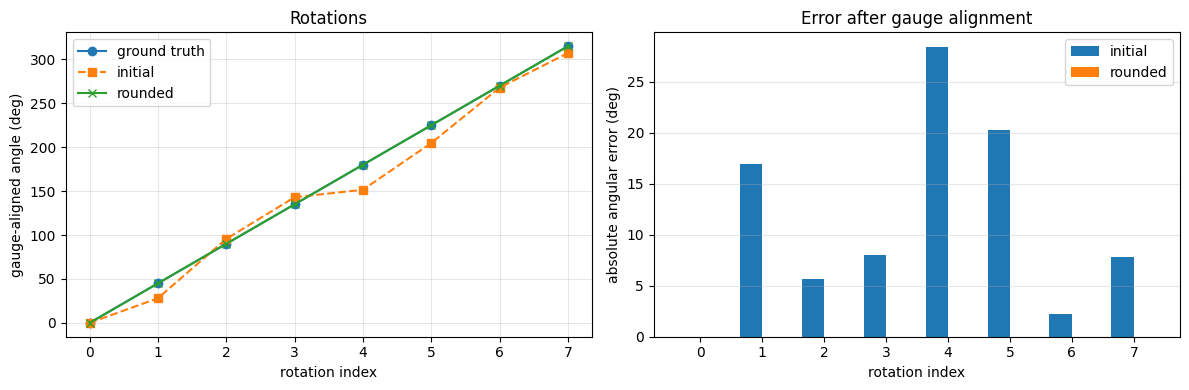

In [6]:
indices = np.arange(num_rotations)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(indices, np.rad2deg(truth_angles), "o-", label="ground truth")
axes[0].plot(indices, np.rad2deg(initial_aligned_angles), "s--", label="initial")
axes[0].plot(indices, np.rad2deg(rounded_aligned_angles), "x-", label="rounded")
axes[0].set(xlabel="rotation index", ylabel="gauge-aligned angle (deg)", title="Rotations")
axes[0].grid(alpha=0.3)
axes[0].legend()

width = 0.36
axes[1].bar(indices - width / 2, initial_error, width, label="initial")
axes[1].bar(indices + width / 2, rounded_error, width, label="rounded")
axes[1].set(xlabel="rotation index", ylabel="absolute angular error (deg)", title="Error after gauge alignment")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()
plt.tight_layout()

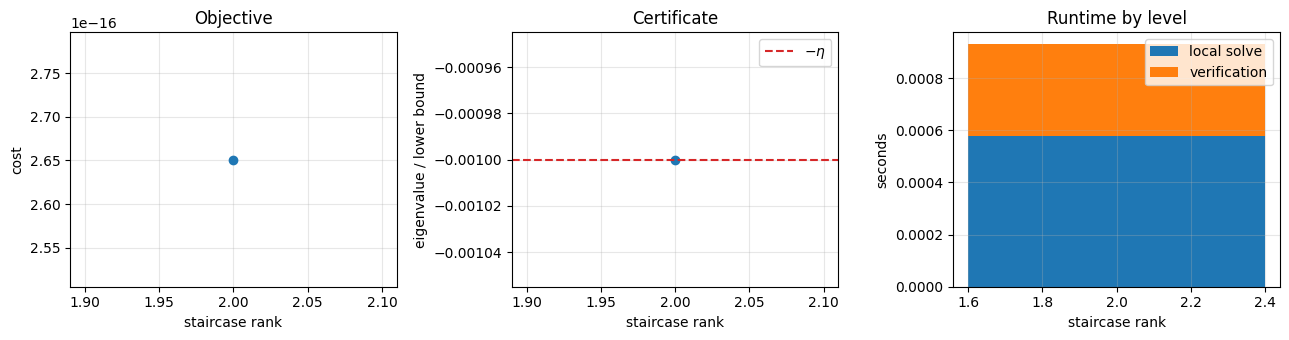

In [7]:
ranks = np.asarray(result.getRanksVisited())
costs = np.asarray(result.getCostPerLevel())
eigenvalues = np.asarray(result.getMinEigenvaluePerLevel())
nlp_times = np.asarray(result.getNlpTimePerLevel())
verify_times = np.asarray(result.getVerifyTimePerLevel())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(ranks, costs, "o-")
axes[0].set(xlabel="staircase rank", ylabel="cost", title="Objective")
axes[1].plot(ranks, eigenvalues, "o-")
axes[1].axhline(-params.eta, color="tab:red", linestyle="--", label="$-\\eta$")
axes[1].set(xlabel="staircase rank", ylabel="eigenvalue / lower bound", title="Certificate")
axes[1].legend()
axes[2].bar(ranks, nlp_times, label="local solve")
axes[2].bar(ranks, verify_times, bottom=nlp_times, label="verification")
axes[2].set(xlabel="staircase rank", ylabel="seconds", title="Runtime by level")
axes[2].legend()
for axis in axes:
    axis.grid(alpha=0.3)
plt.tight_layout()

## Solve the lifted SDP with MOSEK

The staircase above does not require a commercial solver. The next two approaches use GTSAM's optional MOSEK wrappers and therefore require a GTSAM build with `GTSAM_WITH_MOSEK=ON` and a valid MOSEK license.

For the explicit SDP formulations, we remove the global rotation gauge by fixing $R_0=I$ with a hard Frobenius prior. The remaining ring factors are unchanged.

In [8]:
try:
    from gtsam import (
        ChordalOrderingType,
        MosekChordalSDP,
        MosekMonolithicSDP,
    )
except ImportError:
    has_mosek_sdp = False
    print("This GTSAM build does not include the optional MOSEK SDP wrappers.")
else:
    has_mosek_sdp = True
    mosek_graph = gtsam.NonlinearFactorGraph()
    mosek_graph.add(
        gtsam.FrobeniusPriorRot2(
            X(0),
            gtsam.Rot2.Identity().matrix(),
            gtsam.noiseModel.Constrained.All(4),
        )
    )
    for index in range(num_rotations):
        next_index = (index + 1) % num_rotations
        measurement = ground_truth[index].between(ground_truth[next_index])
        mosek_graph.add(
            gtsam.FrobeniusBetweenFactorRot2(
                X(index), X(next_index), measurement
            )
        )
    mosek_problem = gtsam.QcqpProblem(mosek_graph)
    print(f"Gauge-fixed QCQP with {mosek_graph.size()} factors")

Gauge-fixed QCQP with 9 factors


### Monolithic SDP

`MosekMonolithicSDP` places the complete lifted matrix in one positive-semidefinite cone.

In [9]:
if has_mosek_sdp:
    monolithic = MosekMonolithicSDP(mosek_problem)
    if not monolithic.solve():
        raise RuntimeError("The monolithic MOSEK solve did not complete.")
    monolithic.recoverQcqpValues()

    monolithic_values = gtsam.extractQcqpValuesRot2(monolithic.getRecoveredQcqpValues())
    monolithic_poses = [monolithic_values.atRot2(X(i)) for i in range(num_rotations)]
    monolithic_errors = [abs(ground_truth[i].between(monolithic_poses[i]).theta()) for i in range(num_rotations)]
    print(f"Status: {monolithic.problemStatus()}")
    print(f"Objective: {monolithic.objectiveValue():.6g}")
    print(f"MOSEK time: {monolithic.solveTimeSeconds():.3f} s")
    print(f"Maximum Rot2 error: {max(monolithic_errors):.3e}")

Status: ProblemStatus::PrimalAndDualFeasible
Objective: 2.90223e-12
MOSEK time: 0.007 s
Maximum Rot2 error: 2.322e-12


### Chordal SDP

`MosekChordalSDP` uses a symbolic elimination ordering to replace the single cone with smaller clique cones. Here COLAMD selects the ordering, and the resulting Bayes tree exposes the decomposition.

In [10]:
if has_mosek_sdp:
    chordal = MosekChordalSDP(mosek_problem, ChordalOrderingType.Colamd)
    if not chordal.solve():
        raise RuntimeError("The chordal MOSEK solve did not complete.")
    chordal.recoverQcqpValues()

    chordal_values = gtsam.extractQcqpValuesRot2(chordal.getRecoveredQcqpValues())
    chordal_poses = [chordal_values.atRot2(X(i)) for i in range(num_rotations)]
    chordal_errors = [abs(ground_truth[i].between(chordal_poses[i]).theta()) for i in range(num_rotations)]
    print(f"Status: {chordal.problemStatus()}")
    print(f"Objective: {chordal.objectiveValue():.6g}")
    print(f"MOSEK time: {chordal.solveTimeSeconds():.3f} s")
    print(f"Bayes-tree cliques: {chordal.bayesTree().size()}")
    print(f"Maximum Rot2 error: {max(chordal_errors):.3e}")

Status: ProblemStatus::PrimalAndDualFeasible
Objective: 5.36193e-12
MOSEK time: 0.012 s
Bayes-tree cliques: 6
Maximum Rot2 error: 7.997e-12


The Riemannian Staircase certifies the relaxation without a commercial solver, while the two optional MOSEK paths solve the gauge-fixed relaxation directly. The monolithic formulation uses one PSD cone; the chordal formulation uses the Bayes-tree cliques to split it into smaller cones.